# Test No.1: Training and testing the newly refactored Classifer

## Imports before training

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split

from src.classifiers import (
    ResNet18_CBAM,
    CelebADataset,
    inference_single_image,
    visualize_integrated_gradients,
    SELECTED_ATTRIBUTES,
 )
from src.classifiers.trainer.training_script import train_resnet18_cbam

## Configs and functions Dataloader preparations

In [2]:
# --- CONFIGURATION ---
BATCH_SIZE = 128
IMAGE_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CSV_PATH = r"./Dataset/celeba_70percent_721/train/list_attr_celeba.csv"
IMAGE_PATH = r"./Dataset/celeba_70percent_721/train/img_align_celeba"
PATH_CHECKPOINT = r"./outputs/classifier/checkpoints/resnet18_cbam_128_05_3"
NUM_CLASSES = len(SELECTED_ATTRIBUTES)
LEARNING_RATE = 0.001
NUM_EPOCHS = 5
WEIGHT_DECAY = 1e-4

# Tạo thư mục checkpoint
os.makedirs(PATH_CHECKPOINT, exist_ok=True)

In [3]:
# Load CSV
print("Loading CSV metadata...")
df_attr = pd.read_csv(CSV_PATH, index_col=0)
missing_attrs = [attr for attr in SELECTED_ATTRIBUTES if attr not in df_attr.columns]
if missing_attrs:
    raise ValueError(f"Missing required CelebA attributes: {missing_attrs}")
df_attr = df_attr.loc[:, SELECTED_ATTRIBUTES]
attribute_names = SELECTED_ATTRIBUTES

# Split Train/Val (90/10)
train_df, val_df = train_test_split(df_attr, test_size=0.1, random_state=42)

# Tính toán pos_weight cho Loss Function dựa trên tập Train
# pos_weight = (num_neg) / (num_pos) cho từng class
print("Calculating positive weights for loss function...")
train_labels = train_df.replace(-1, 0).values
num_pos = np.sum(train_labels, axis=0)
num_neg = len(train_df) - num_pos
# Thêm epsilon để tránh chia cho 0
pos_weights_tensor = torch.tensor(num_neg / (num_pos + 1e-5), dtype=torch.float32).to(DEVICE)

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

viz_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

train_dataset = CelebADataset(train_df, IMAGE_PATH, transform=train_transform)
val_dataset = CelebADataset(val_df, IMAGE_PATH, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True, prefetch_factor=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True, prefetch_factor=4)

print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")

Loading CSV metadata...
Calculating positive weights for loss function...
Train size: 89344 | Val size: 9928


In [4]:
# --- 3. MODEL, OPTIMIZER, LOSS SETUP ---

print(f"Initializing ResNet18 + CBAM on {DEVICE}...")
model = ResNet18_CBAM(num_classes=NUM_CLASSES)
model = model.to(DEVICE)

# Loss function với pos_weight xử lý imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# LR Scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

Initializing ResNet18 + CBAM on cuda...


## Training the model

In [5]:
# --- 4. TRAINING LOOP ---
print("Starting training loop...")

history = train_resnet18_cbam(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    attribute_names=attribute_names,
    checkpoint_dir=PATH_CHECKPOINT,
    checkpoint_prefix="resnet18_cbam",
    save_every=5,
    threshold=0.5,
)

Starting training loop...


Epoch 1/5 [Val]: 100%|██████████| 78/78 [00:57<00:00,  1.36it/s]



--- Epoch 1 Report ---
LR: 0.001000 | Train Loss: 0.3754 | Val Loss: 0.3468 | Mean Val Acc: 0.8959
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
Bald                      | 0.9782     | 0.0445
Bangs                     | 0.9336     | 0.2127
Black_Hair                | 0.8824     | 0.2248
Blond_Hair                | 0.9100     | 0.2465
Brown_Hair                | 0.6981     | 0.4896
Bushy_Eyebrows            | 0.8796     | 0.2419
Eyeglasses                | 0.9912     | 0.0723
Male                      | 0.9620     | 0.4432
Mouth_Slightly_Open       | 0.9253     | 0.5033
Mustache                  | 0.9144     | 0.1362
Pale_Skin                 | 0.8918     | 0.1596
Young                     | 0.7843     | 0.6328
------------------------------------------------------------


Epoch 2/5 [Val]: 100%|██████████| 78/78 [00:43<00:00,  1.79it/s]



--- Epoch 2 Report ---
LR: 0.001000 | Train Loss: 0.3105 | Val Loss: 0.3162 | Mean Val Acc: 0.9059
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
Bald                      | 0.9488     | 0.0764
Bangs                     | 0.9403     | 0.1969
Black_Hair                | 0.8722     | 0.3280
Blond_Hair                | 0.9387     | 0.1958
Brown_Hair                | 0.7977     | 0.3645
Bushy_Eyebrows            | 0.8794     | 0.2405
Eyeglasses                | 0.9920     | 0.0758
Male                      | 0.9695     | 0.4351
Mouth_Slightly_Open       | 0.9274     | 0.4546
Mustache                  | 0.9082     | 0.1347
Pale_Skin                 | 0.8899     | 0.1633
Young                     | 0.8066     | 0.6377
------------------------------------------------------------


...


--- Epoch 3 Report ---
LR: 0.001000 | Train Loss: 0.2939 | Val Loss: 0.3076 | Mean Val Acc: 0.8930
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
Bald                      | 0.9509     | 0.0740
Bangs                     | 0.9201     | 0.2328
Black_Hair                | 0.8813     | 0.3071
Blond_Hair                | 0.9118     | 0.2416
Brown_Hair                | 0.7987     | 0.3621
Bushy_Eyebrows            | 0.8142     | 0.3362
Eyeglasses                | 0.9899     | 0.0804
Male                      | 0.9707     | 0.4212
Mouth_Slightly_Open       | 0.9279     | 0.4746
Mustache                  | 0.9015     | 0.1433
Pale_Skin                 | 0.8391     | 0.2161
Young                     | 0.8094     | 0.6361
------------------------------------------------------------


Epoch 4/5 [Val]: 100%|██████████| 78/78 [00:58<00:00,  1.34it/s]



--- Epoch 4 Report ---
LR: 0.001000 | Train Loss: 0.2793 | Val Loss: 0.3080 | Mean Val Acc: 0.9047
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
Bald                      | 0.9786     | 0.0402
Bangs                     | 0.9354     | 0.2107
Black_Hair                | 0.8852     | 0.3174
Blond_Hair                | 0.9115     | 0.2354
Brown_Hair                | 0.8137     | 0.3475
Bushy_Eyebrows            | 0.7912     | 0.3537
Eyeglasses                | 0.9874     | 0.0817
Male                      | 0.9772     | 0.4181
Mouth_Slightly_Open       | 0.9326     | 0.4627
Mustache                  | 0.9192     | 0.1240
Pale_Skin                 | 0.9321     | 0.1046
Young                     | 0.7927     | 0.5880
------------------------------------------------------------


Epoch 5/5 [Val]: 100%|██████████| 78/78 [00:40<00:00,  1.93it/s]


--- Epoch 5 Report ---
LR: 0.001000 | Train Loss: 0.2688 | Val Loss: 0.3102 | Mean Val Acc: 0.9134
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
Bald                      | 0.9780     | 0.0409
Bangs                     | 0.9358     | 0.2084
Black_Hair                | 0.8572     | 0.3581
Blond_Hair                | 0.9421     | 0.1921
Brown_Hair                | 0.8105     | 0.3513
Bushy_Eyebrows            | 0.8574     | 0.2752
Eyeglasses                | 0.9850     | 0.0828
Male                      | 0.9707     | 0.4027
Mouth_Slightly_Open       | 0.9333     | 0.4711
Mustache                  | 0.9337     | 0.1037
Pale_Skin                 | 0.9124     | 0.1301
Young                     | 0.8444     | 0.6891
------------------------------------------------------------
Saved checkpoint: ./outputs/classifier/checkpoints/resnet18_cbam_128_05_3\resnet1

## Saliency validation

In [7]:
# --- 5. INFERENCE ON SINGLE IMAGE ---
print("Loading best model for inference...")
model.load_state_dict(torch.load(os.path.join(PATH_CHECKPOINT, "best_model.pth"), map_location=DEVICE))
model.to(DEVICE)
model.eval()

# Chọn 1 ảnh ngẫu nhiên từ validation set để test
sample_img_name = val_df.index[320]  # Lấy ảnh bất kỳ trong val set
sample_img_path = os.path.join(IMAGE_PATH, sample_img_name)

print(f"Testing inference on: {sample_img_name}")

# Run inference (threshold 0.5)
probs, preds, gt = inference_single_image(
    model=model,
    image_path=sample_img_path,
    transform=val_transform,
    attribute_names=attribute_names,
    device=DEVICE,
    df_attr=df_attr,
    threshold=0.5
)

# --- TEST VỚI NHIỀU ẢNH (Optional) ---
print("\n" + "="*80)
print("Testing on multiple random images from validation set:")
print("="*80)

np.random.seed(42)
random_indices = np.random.choice(len(val_df), size=min(3, len(val_df)), replace=False)

for idx in random_indices:
    img_name = val_df.index[idx]
    img_path = os.path.join(IMAGE_PATH, img_name)
    
    inference_single_image(
        model=model,
        image_path=img_path,
        transform=val_transform,
        attribute_names=attribute_names,
        device=DEVICE,
        df_attr=df_attr,
        threshold=0.9
)

Loading best model for inference...
Testing inference on: 084250.jpg

Inference Result for: 084250.jpg
Attribute                 | Ground Truth  | Pred Prob  | Prediction  | Correct
--------------------------------------------------------------------------------
Bald                      | 0             | 0.0000     | 0           | ✓      
Bangs                     | 0             | 0.0007     | 0           | ✓      
Black_Hair                | 0             | 0.1777     | 0           | ✓      
Blond_Hair                | 0             | 0.0010     | 0           | ✓      
Brown_Hair                | 1             | 0.8479     | 1           | ✓      
Bushy_Eyebrows            | 0             | 0.0704     | 0           | ✓      
Eyeglasses                | 0             | 0.0000     | 0           | ✓      
Male                      | 0             | 0.0000     | 0           | ✓      
Mouth_Slightly_Open       | 1             | 0.5290     | 1           | ✓      
Mustache                  

Visualizing Integrated Gradients for attribute: Brown_Hair

=== Integrated Gradients for POSITIVE class ===


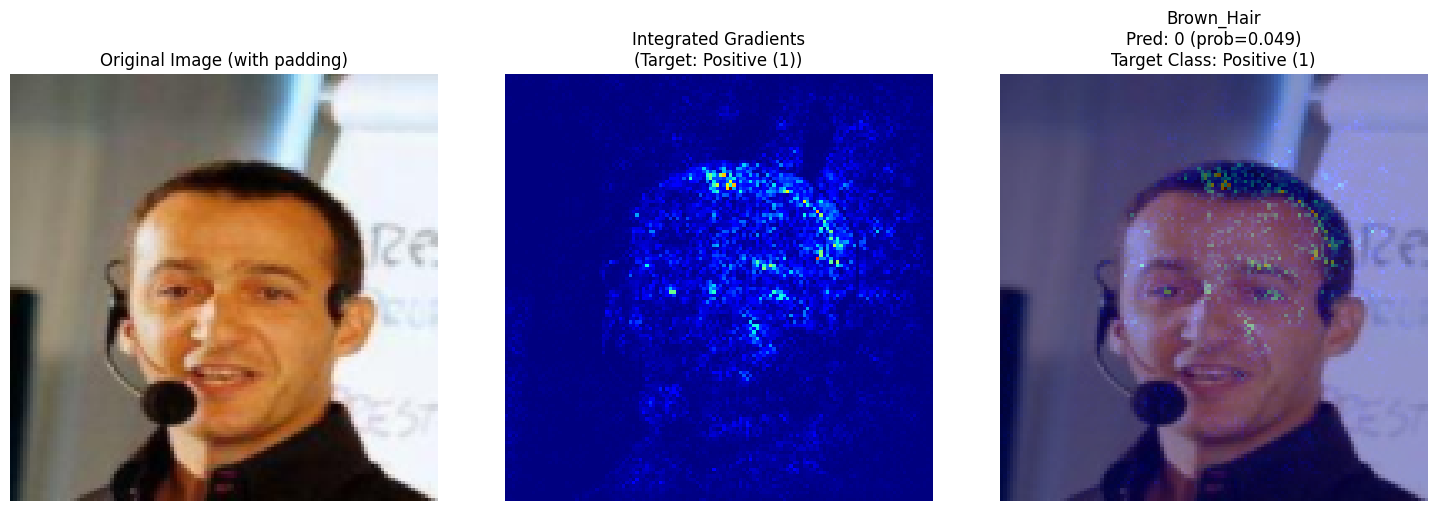


=== Integrated Gradients for NEGATIVE class ===


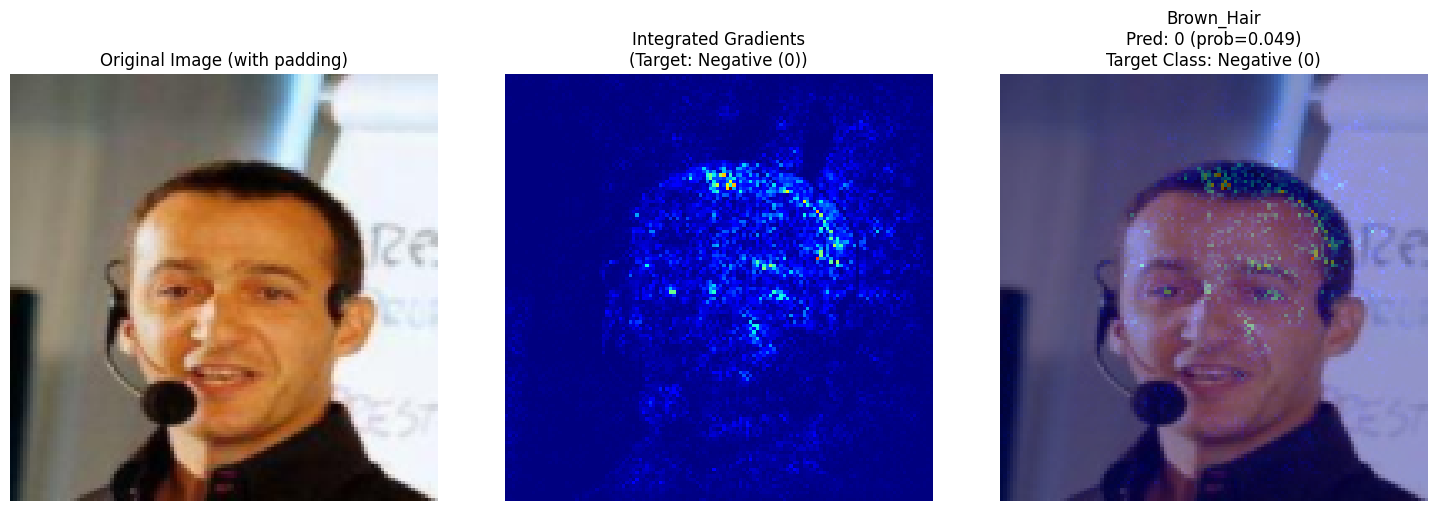

In [8]:
# --- 8. INTEGRATED GRADIENTS ---
model.eval()

sample_img_path = os.path.join(IMAGE_PATH, val_df.index[127])
attr_idx = attribute_names.index("Brown_Hair")

print(f"Visualizing Integrated Gradients for attribute: {attribute_names[attr_idx]}")

# Visualize for POSITIVE class
print("\n=== Integrated Gradients for POSITIVE class ===")
visualize_integrated_gradients(
    model=model,
    image_path=sample_img_path,
    attribute_idx=attr_idx,
    attribute_name=attribute_names[attr_idx],
    transform=val_transform,
    viz_transform=viz_transform,
    device=DEVICE,
    target_class=1,
    steps=50,
    alpha=0.4,
    image_size=IMAGE_SIZE
)

# Visualize for NEGATIVE class
print("\n=== Integrated Gradients for NEGATIVE class ===")
visualize_integrated_gradients(
    model=model,
    image_path=sample_img_path,
    attribute_idx=attr_idx,
    attribute_name=attribute_names[attr_idx],
    transform=val_transform,
    viz_transform=viz_transform,
    device=DEVICE,
    target_class=0,
    steps=50,
    alpha=0.4,
    image_size=IMAGE_SIZE
)

# Test No.2: Training and testing the newly refactored vq_vae

### HR-VQGAN Training Setup
Initialize and configure the HR-VQGAN (Hierarchical Residual VQ-VAE with Discriminator) for unsupervised training on CelebA.

In [1]:
from src.synthesis.config import Config
import torch
cfg = Config()
cfg.decoder_pretrain_epochs = 10
cfg.decoder_lr = 1e-3
cfg.decoder_checkpoint_dir = "outputs/synth_network/decoder/sharpened"
cfg.decoder_checkpoint_path = "outputs/synth_network/decoder/sharpened/latest_sharp.pth"
cfg.vqvae_checkpoint = "outputs/synth_network/hr_vqvae/best_gan.pth"
cfg.batch_size = 32
cfg.num_epochs = 30
cfg.num_workers = 8
cfg.learning_rate = 1e-4
cfg.data_root = "/mnt/c/for exports/ceGAN/Dataset/celeba_70percent_721/test"
cfg.classifier_checkpoint = "outputs/cnn_classfier/resnet18_cbam_epoch_10_128.pth"
cfg.use_ig = False
cfg.gradcamplusplus_use = False

# Latent-space blend (inside generator)
cfg.use_decoder_blend = True

# IMPORTANT: IG alignment is expensive and can encourage "cheating" artifacts (leak).
# Start with it off; re-enable later with a tiny weight if needed.
cfg.align_weight = 0
cfg.align_interval = 0

# Train only a restricted set of attributes
cfg.active_attributes = [
    'Brown_Hair',
]
cfg.max_active_attributes_per_epoch = len(cfg.active_attributes)

# Reduce global modulation leak
cfg.decoder_w_from_orig = True

# Mutator steps: keep edits small early (prevents immediate leak/blur)
cfg.mutator_step_bias_init = -2.0
cfg.mutator_step_scale = 1.2
cfg.mutator_mid_mult = 1.2

# Hard quantization schedule: ramp instead of a hard switch at epoch 5
cfg.hard_start_epoch = 5
cfg.hard_ramp_epochs = 20
cfg.adv_weight = 1.0
# StyleGAN Decoder Pre-Training
from src.synthesis.dataset import get_loader
from src.synthesis.train_comprehensive import ComprehensiveTrainer

loader_train = get_loader(cfg, split='train', batch_size=cfg.batch_size,num_workers=cfg.num_workers, shuffle=True)
loader_val = get_loader(cfg, split='val', batch_size=cfg.batch_size, num_workers=cfg.num_workers, shuffle=False, return_filename=True)

HVQ-GAN TRAINING V3

Configuration:
   Device: cuda
   Image Size: 128x128
   Batch Size: 16
   Total Steps: 50,000
   Log Interval: 1 steps
   Save Interval: 2,500 steps
   Sample Interval: 1,000 steps
   Discriminator Start: Step 40,000
   Learning Rate: 0.0003
   Use AMP: False (disabled for stability)
   Loss Weights: {'recon': 1.0, 'vq': 1.0, 'perceptual': 1.0, 'disc': 0.8}

Found 99272 training images

Starting step-based training...

🔧 HVQ-GAN TRAINING V3 (Step-based, Unsupervised)
Device: cuda
Total Steps: 50,000
Batch Size: 16
Log Interval: 1 steps
Save Interval: 2,500 steps
Sample Interval: 1,000 steps
📁 Output Directory: ./outputs/latent_space/hrvqvae(rerun)
   ├── checkpoints/              (model checkpoints)
   ├── samples/                  (progressive decoding visualizations)
   ├── metrics_and_visualisations/ (training metrics & analysis)
   └── logs/                     (training logs)



a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\src\latentspace\trainer.py:273: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_g = GradScaler(enabled=cfg.use_amp)
a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\src\latentspace\trainer.py:274: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_d = GradScaler(enabled=cfg.use_amp)
a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\cegan.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Cou

Loading VGG for Perceptual Loss...
✅ VGG loaded

Training images: 99272
Batches per cycle: 6205

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\cegan.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\cegan.venv\Lib\site-packages\lpips\weights\v0.1\alex.pth


...

   ✅ New best (no_gan) @ step 5,000: PSNR=22.959, SSIM=0.8083 -> best_no_gan.pth

📊 CREATING EVALUATION REPORT AT STEP 5,000
✅ Loss curves saved: loss_curves_step_5000.png
✅ Metrics comparison saved: metrics_comparison_step_5000.png
✅ Cascade hierarchy saved: cascade_hierarchy_step_5000.png
✅ Codebook usage saved: codebook_usage_step_5000.png
✅ Codebook analysis saved: codebook_analysis_step_5000.txt

   Metrics history: metrics_history.csv

✅ Step 5,000 Checkpoint:
   Checkpoint: checkpoint_step_5000.pth
   Metrics: MSE=0.0202, PSNR=22.96 dB, SSIM=0.808, LPIPS=0.1163
   Codebook: Top usage=9.2%, Mid usage=77.0%, Bottom usage=99.8%


Training:  15%|█▌        | 7500/50000 [13:27<1:11:43,  9.88step/s, Tot=0.8236, Rec=0.0846, Rtot=0.8236, VQ=0.0419, Perc=0.6971, Ppl=269.83, LPIPS=0.4052] 


📊 CREATING EVALUATION REPORT AT STEP 7,500
✅ Loss curves saved: loss_curves_step_7500.png
✅ Metrics comparison saved: metrics_comparison_step_7500.png
✅ Cascade hierarchy saved: cascade_hierarchy_step_7500.png
✅ Codebook usage saved: codebook_usage_step_7500.png
✅ Codebook analysis saved: codebook_analysis_step_7500.txt

   Metrics history: metrics_history.csv

✅ Step 7,500 Checkpoint:
   Checkpoint: checkpoint_step_7500.pth
   Metrics: MSE=0.0846, PSNR=16.75 dB, SSIM=0.436, LPIPS=0.4052
   Codebook: Top usage=12.3%, Mid usage=99.2%, Bottom usage=100.0%


Training:  20%|██        | 10000/50000 [17:59<1:10:56,  9.40step/s, Tot=0.2638, Rec=0.0135, Rtot=0.2638, VQ=0.0396, Perc=0.2106, Ppl=247.35, LPIPS=0.0728]

Loaded train split: 9928 images
Loaded val split: 1418 images


In [ ]:
# Comprehensive Counterfactual Training
from importlib import reload
from src.synthesis import train_comprehensive as train_comprehensive_module
train_comprehensive_module = reload(train_comprehensive_module)
from src.synthesis.train_comprehensive import ComprehensiveTrainer
import torch.multiprocessing as mp
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler

# cfg.sharpened_decoder_path = "outputs/synth_network/stylegan_decoder_sharpened/latest_sharp.pth"
 
trainer = ComprehensiveTrainer(cfg, experiment_name="ceGAN_counterfactual",device="cuda:0")
trainer.train(
    num_epochs=cfg.num_epochs,
    loader_train=loader_train,
    loader_val=loader_val
)

Experiment directory: outputs/synth_network/CF_generator/ceGAN_counterfactual_20260221_no_ig
Number of classes for classifier: 12 | Using ResNet18_CBAM
Loading sharpened StyleGAN decoder from outputs/synth_network/stylegan_decoder_sharpened/latest_sharp.pth...
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [on]
Loading model from: /home/vupham/miniconda3/envs/kltn/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth
Adversarial loss weight: 1.0
Loaded decoder weights from outputs/synth_network/decoder/sharpened/latest_sharp.pth (decoder checkpoint)
GradCamPlusPlus Layer: CBAMBlock(
  (ca): ChannelAttention(
    (avg_pool): AdaptiveAvgPool2d(output_size=1)
    (max_pool): AdaptiveMaxPool2d(output_size=1)
    (fc1): Conv2d(512, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (relu): ReLU()
    (fc2): Conv2d(32, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (sigmoid): Sigmoid()
  )
  (sa): SpatialAttention(
    (conv1): Conv2d(2, 1, kernel_size=(7, 7)

Epoch 0 / 30:   0%|          | 0/310 [00:00<?, ?it/s]/home/vupham/Counterfactual-explanation-for-classifer-with-stylegan2/src/synthesis/train_comprehensive.py:941: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 0 / 30:   5%|▌         | 16/310 [00:14<02:52,  1.70it/s, loss=2.3837, cf=0.263, ret=0.000, adv=0.143, d=1.996]

# Test 4: Running thesis proofs on the ingenuity of the project

## Phase 1(Fidelity on recon test) and phase 2 (inference speed test)

In [1]:
# Run Phase 1 (fidelity), Phase 2 (speed), and Aux metrics via the novelty_proofs delegator
import os, json, subprocess, sys
from pathlib import Path
from datetime import datetime

# Adjust these paths before running
VQVAE_CKPT = Path("./outputs/export_models/hr_vqvae/best_gan.pth")
DECODER_CKPT = Path("./outputs/export_models/decoder/sharpened/latest_sharp.pth")
CLASSIFIER_CKPT = Path("./outputs/classifier/checkpoints/resnet18_cbam_128_05_3/best_model.pth")
IMAGE_DIR = Path("Dataset/celeba_70percent_721/val")
OUT_DIR = Path("outputs/novelty_proofs/notebook_runs")
DEVICE = "cuda"

# Competitor recon roots (auto-detected subfolders: attgan/starganv2/dive/AttGAN-PyTorch/stargan-v2/LDCE)
COMP_ROOT = Path("./competitor_models")

# Optional Wachter recon directory (set to None to skip)
WACHTER_DIR = None  # e.g., Path("./competitor_models/recons/wachter_recons")

# Aux metric inputs (point to your validation_simple folder)
AUX_SHARED_DIR = Path("./outputs/temp_synth/ceGAN_counterfactual_mouth_slightly_open_final/visualizations/validation_simple")
AUX_ORIG_DIR = AUX_SHARED_DIR  # originals and cfs live together
AUX_CF_DIR = AUX_SHARED_DIR
AUX_ORIG_GLOB = "orig_*"
AUX_CF_GLOB = "cf_*"
AUX_TARGET_ATTR = "Mouth_Slightly_Open"  # can be attribute name or index string

# Ensure output folders exist
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Helper to run a CLI command and stream output

def run_cmd(cmd, workdir=None):
    print(f"\n[cmd] {' '.join(cmd)}")
    proc = subprocess.Popen(
        cmd,
        cwd=workdir,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        encoding="utf-8",
        errors="replace",
    )
    for line in proc.stdout:
        print(line, end="")
    proc.wait()
    if proc.returncode != 0:
        raise RuntimeError(f"Command failed with code {proc.returncode}: {' '.join(cmd)}")

# Phase 1: Fidelity (FID + optional LPIPS/SSIM + optional Wachter recon metrics)
fidelity_dir = OUT_DIR / "fidelity_test"
fidelity_cmd = [
    sys.executable,
    "-m",
    "src.testing_suite.novelty_proofs",
    "fidelity",
    "--vqvae_ckpt",
    str(VQVAE_CKPT),
    "--decoder_ckpt",
    str(DECODER_CKPT),
    "--image_dir",
    str(IMAGE_DIR),
    "--output_dir",
    str(fidelity_dir),
    "--num_samples",
    "64",
    "--batch_size",
    "8",
    "--compute_fid",
    "--compute_lpips",
    "--compute_ssim",
    "--device",
    DEVICE,
    "--competitor_root",
    str(COMP_ROOT),
    "--auto_wachter",
]
if WACHTER_DIR:
    fidelity_cmd += ["--wachter_dir", str(WACHTER_DIR)]
else:
    print("[info] Wachter dir not set; skipping Wachter metrics. Set WACHTER_DIR to enable.")
run_cmd(fidelity_cmd, workdir=Path.cwd())

# Phase 2: Speed (mutator vs. Wachter baseline; diffusion optional if installed)
speed_dir = OUT_DIR / "speed_test"
speed_cmd = [
    sys.executable,
    "-m",
    "src.testing_suite.novelty_proofs",
    "speed",
    "--batch_size",
    "32",
    "--repeats",
    "20",
    "--wachter_steps",
    "50",
    "--device",
    DEVICE,
    "--output_dir",
    str(speed_dir),
    "--diffusion_model",
    "runwayml/stable-diffusion-v1-5",
]
run_cmd(speed_cmd, workdir=Path.cwd())

# Phase 3: Aux metrics (identity / validity / sparsity)
aux_dir = OUT_DIR / "aux_test"
aux_dir.mkdir(parents=True, exist_ok=True)
if not CLASSIFIER_CKPT.exists():
    print(f"Skipping aux metrics: classifier ckpt missing at {CLASSIFIER_CKPT}")
elif not (AUX_ORIG_DIR.exists() and AUX_CF_DIR.exists()):
    print(f"Skipping aux metrics: update AUX_ORIG_DIR ({AUX_ORIG_DIR}) / AUX_CF_DIR ({AUX_CF_DIR}) to valid folders.")
else:
    aux_cmd = [
        sys.executable,
        "-m",
        "src.testing_suite.novelty_proofs",
        "aux",
        "--classifier_ckpt",
        str(CLASSIFIER_CKPT),
        "--orig_dir",
        str(AUX_ORIG_DIR),
        "--cf_dir",
        str(AUX_CF_DIR),
        "--orig_glob",
        AUX_ORIG_GLOB,
        "--cf_glob",
        AUX_CF_GLOB,
        "--target_attr",
        str(AUX_TARGET_ATTR),
        "--device",
        DEVICE,
        "--output_file",
        str(aux_dir / "aux_metrics.json"),
    ]
    run_cmd(aux_cmd, workdir=Path.cwd())

# Summaries
print("\nFidelity outputs:", fidelity_dir)
print("Speed outputs:", speed_dir)
print("Aux outputs:", aux_dir)
if (fidelity_dir / "fidelity_metrics.json").exists():
    fid_metrics = json.load(open(fidelity_dir / "fidelity_metrics.json"))
    print("Fidelity metrics:", fid_metrics)
    if isinstance(fid_metrics, dict):
        # Try common Wachter locations
        if "wachter" in fid_metrics:
            print("Wachter metrics:", fid_metrics["wachter"])
        elif "competitors" in fid_metrics and "wachter" in fid_metrics["competitors"]:
            print("Wachter metrics:", fid_metrics["competitors"]["wachter"])
else:
    print("Fidelity metrics: not generated (check paths above).")
if (speed_dir / "speed_results.json").exists():
    print("Speed metrics:", json.load(open(speed_dir / "speed_results.json")))
if (aux_dir / "aux_metrics.json").exists():
    print("Aux metrics:", json.load(open(aux_dir / "aux_metrics.json")))
else:
    print("Aux metrics: not generated (check paths above).")


[info] Wachter dir not set; skipping Wachter metrics. Set WACHTER_DIR to enable.

[cmd] a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\cegan.venv\Scripts\python.exe -m src.testing_suite.novelty_proofs fidelity --vqvae_ckpt outputs\export_models\hr_vqvae\best_gan.pth --decoder_ckpt outputs\export_models\decoder\sharpened\latest_sharp.pth --image_dir Dataset\celeba_70percent_721\val --output_dir outputs\novelty_proofs\notebook_runs\fidelity_test --num_samples 64 --batch_size 8 --compute_fid --compute_lpips --compute_ssim --device cuda --competitor_root competitor_models --auto_wachter
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\cegan.venv\Lib\site-packages\lpips\weights\v0.1\alex.pth
a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classi

## Common paths setup

In [1]:
# Common paths and helpers for competitor recon generation
import sys
import subprocess
from pathlib import Path
import os
from collections import deque

# Validation set and attributes
VAL_ROOT = Path("./Dataset/celeba_70percent_721/val")
VAL_IMG_DIR = VAL_ROOT / "img_align_celeba"
if not VAL_IMG_DIR.exists():
    VAL_IMG_DIR = VAL_ROOT  # fallback
ATTR_LIST = VAL_ROOT / "list_attr_celeba.csv"  # attribute file for alignment

# Output root for competitor reconstructions (picked up by fidelity_test)
COMP_ROOT = Path("./competitor_models")
COMP_ROOT.mkdir(exist_ok=True)


def run_cmd(cmd, workdir=None, tail_lines=50):
    env = os.environ.copy()
    env.setdefault("PYTHONFAULTHANDLER", "1")  # show native tracebacks on crash
    env.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # avoid MKL aborts on Windows
    print("\n[cmd]", " ".join(cmd))
    proc = subprocess.Popen(
        cmd,
        cwd=workdir,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        encoding="utf-8",
        errors="replace",
        env=env,
    )
    tail = deque(maxlen=tail_lines)
    for line in proc.stdout:
        print(line, end="")
        tail.append(line)
    proc.wait()
    if proc.returncode != 0:
        print(f"[error] exit code {proc.returncode}; tail output:")
        print("".join(tail))
        raise RuntimeError(f"Command failed ({proc.returncode})")

## Competitor 1: AttGAN (baseline)

In [2]:
# AttGAN: generate reconstructions from validation set (uses custom val attrs)
import sys
import pandas as pd
import shutil

ATTGAN_ATTRS = [
    "Bald",
    "Bangs",
    "Black_Hair",
    "Blond_Hair",
    "Brown_Hair",
    "Bushy_Eyebrows",
    "Eyeglasses",
    "Male",
    "Mouth_Slightly_Open",
    "Mustache",
    "No_Beard",
    "Pale_Skin",
    "Young",
]

attgan_script = (COMP_ROOT / "AttGAN-PyTorch" / "test.py").resolve()
attgan_ckpt = (COMP_ROOT / "AttGAN-PyTorch" / "output/128_shortcut1_inject0_none/checkpoint/weights.49.pth").resolve()
attgan_attr_csv = ATTR_LIST.resolve()
attgan_attr_txt = (COMP_ROOT / "AttGAN-PyTorch" / "val_attrs.txt").resolve()
attgan_output_src = attgan_script.parent / "output" / "128_shortcut1_inject0_none" / "custom_testing"
attgan_out = (COMP_ROOT / "attgan_recons").resolve()
attgan_out.mkdir(exist_ok=True)

if attgan_attr_csv.exists():
    df = pd.read_csv(attgan_attr_csv)
    missing = [c for c in ATTGAN_ATTRS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required attrs in CSV: {missing}")
    subset = df[["index"] + ATTGAN_ATTRS]
    lines = [str(len(subset)), " ".join(ATTGAN_ATTRS)]
    for _, row in subset.iterrows():
        # AttGAN expects 0/1 labels; map -1 -> 0
        vals = ["1" if int(row[attr]) == 1 else "0" for attr in ATTGAN_ATTRS]
        lines.append(" ".join([row["index"]] + vals))
    attgan_attr_txt.write_text("\n".join(lines), encoding="utf-8")
    print(f"[build] wrote {attgan_attr_txt} for {len(subset)} images")
else:
    print(f"[skip] attr CSV missing: {attgan_attr_csv}")

if attgan_script.exists() and attgan_ckpt.exists() and attgan_attr_txt.exists():
    attgan_cmd = [
        sys.executable,
        str(attgan_script),
        "--experiment_name", "128_shortcut1_inject0_none",
        "--load_epoch", "49",  # matches weights.49.pth
        "--custom_img",
        "--custom_data", str(VAL_IMG_DIR.resolve()),
        "--custom_attr", str(attgan_attr_txt),
        "--gpu",
    ]
    run_cmd(attgan_cmd, workdir=attgan_script.parent)
    if attgan_output_src.exists():
        copied = 0
        for img_path in attgan_output_src.glob("*.jpg"):
            shutil.copy2(img_path, attgan_out / img_path.name)
            copied += 1
        print(f"[copy] {copied} files: {attgan_output_src} -> {attgan_out}")
    else:
        print(f"[warn] expected AttGAN outputs missing at {attgan_output_src}")
else:
    print(f"[skip] AttGAN script/ckpt/attr missing: {attgan_script} | {attgan_ckpt} | {attgan_attr_txt}")


[build] wrote A:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\competitor_models\AttGAN-PyTorch\val_attrs.txt for 28363 images

[cmd] a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\cegan.venv\Scripts\python.exe A:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\competitor_models\AttGAN-PyTorch\test.py --experiment_name 128_shortcut1_inject0_none --load_epoch 49 --custom_img --custom_data A:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\Dataset\celeba_70percent_721\val\img_align_celeba --custom_attr A:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\competitor_models\AttGAN-PyTorch\val_attrs.txt --gpu
Namespace(experiment_name='128_shortcut1_inject0_none', test_int=1.0, num_test=None, load_epoc

## Competitor 2: StarGANv2 (ToL - Top-of-the-line)

In [2]:
# StarGANv2 and LDCE (DiVE): generate reconstructions from validation set
 # TODO: set correct checkpoints/configs per repo README.

 # --- StarGANv2 ---
stargan_repo = (COMP_ROOT / "stargan-v2").resolve()
stargan_script = stargan_repo / "main.py"
stargan_ckpt_dir = stargan_repo / "expr" / "checkpoints" / "celeba_hq"
stargan_ckpt = stargan_ckpt_dir / "100000_nets_ema.ckpt"  # <-- set if different
stargan_wing = stargan_repo / "expr" / "checkpoints" / "wing.ckpt"  # face alignment model
stargan_lm = stargan_repo / "expr" / "checkpoints" / "celeba_lm_mean.npz"  # landmark mean
stargan_out = (COMP_ROOT / "stargan_recons").resolve()
stargan_out.mkdir(exist_ok=True)

# Use the bundled celeba_128 src/ref folders; run twice (src, ref) with src==ref to get per-image recon only
stargan_src_dir = stargan_repo / "assets" / "celeba_128" / "src" / "img_align_celeba"
stargan_ref_dir = stargan_repo / "assets" / "celeba_128" / "ref" / "img_align_celeba"

if stargan_script.exists() and stargan_ckpt.exists() and stargan_wing.exists() and stargan_lm.exists():
    runs = [
        ("src", stargan_src_dir),
        ("ref", stargan_ref_dir),
    ]
    for tag, folder in runs:
        subset_out = stargan_out / f"{tag}_recons"
        subset_out.mkdir(exist_ok=True)
        stargan_cmd = [
            sys.executable,
            str(stargan_script),
            "--mode", "sample",            # use the repo's sample mode
            "--skip_video",                 # skip video to save RAM/VRAM
            "--resume_iter", "100000",     # matches ckpt name above
            "--checkpoint_dir", str(stargan_ckpt_dir),
            "--src_dir", str(folder),       # src == ref gives identity recon
            "--ref_dir", str(folder),
            "--result_dir", str(subset_out),
            "--wing_path", str(stargan_wing),
            "--lm_path", str(stargan_lm),
        ]
        print(f"\n[starganv2] recon run for {tag} folder: {folder}")
        run_cmd(stargan_cmd, workdir=stargan_repo)
else:
    print(f"[skip] StarGANv2 missing: script={stargan_script.exists()} ckpt={stargan_ckpt.exists()} wing={stargan_wing.exists()} lm={stargan_lm.exists()}")



[starganv2] recon run for src folder: A:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\competitor_models\stargan-v2\assets\celeba_128\src\img_align_celeba

[cmd] a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\cegan.venv\Scripts\python.exe A:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\competitor_models\stargan-v2\main.py --mode sample --skip_video --resume_iter 100000 --checkpoint_dir A:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\competitor_models\stargan-v2\expr\checkpoints\celeba_hq --src_dir A:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\competitor_models\stargan-v2\assets\celeba_128\src\img_align_celeba --ref_dir A:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactu

In [19]:
# Quick FID check between originals and reconstructions
from pathlib import Path
from PIL import Image
import torch
from torchvision import transforms
from torchmetrics.image.fid import FrechetInceptionDistance

# Point these to your folders
ORIG_DIR = Path("./Dataset/celeba_70percent_721/val/img_align_celeba")
RECON_DIR = Path("./competitor_models/attgan_recons")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
fid = FrechetInceptionDistance(normalize=True).to(device)

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.CenterCrop((128, 128)),
    transforms.ToTensor(),
])

def feed_dir(directory: Path, real: bool):
    images = sorted([p for p in directory.glob("**/*") if p.suffix.lower() in {".jpg", ".png", ".jpeg"}])
    for img_path in images:
        img = Image.open(img_path).convert("RGB")
        x = transform(img).unsqueeze(0).to(device)
        fid.update(x, real=real)
    return len(images)

n_real = feed_dir(ORIG_DIR, real=True)
n_fake = feed_dir(RECON_DIR, real=False)
if n_real == 0 or n_fake == 0:
    raise RuntimeError(f"No images found: real={n_real}, fake={n_fake}")

score = fid.compute().item()
print(f"FID between {ORIG_DIR} (n={n_real}) and {RECON_DIR} (n={n_fake}): {score:.4f}")

FID between Dataset\celeba_70percent_721\val\img_align_celeba (n=28363) and competitor_models\attgan_recons (n=28363): 2.5475


In [ ]:
# AttGAN: generate reconstructions from validation set (uses custom val attrs)
import sys
import pandas as pd
import shutil

ATTGAN_ATTRS = [
    "Bald",
    "Bangs",
    "Black_Hair",
    "Blond_Hair",
    "Brown_Hair",
    "Bushy_Eyebrows",
    "Eyeglasses",
    "Male",
    "Mouth_Slightly_Open",
    "Mustache",
    "No_Beard",
    "Pale_Skin",
    "Young",
]

attgan_script = (COMP_ROOT / "AttGAN-PyTorch" / "test.py").resolve()
attgan_ckpt = (COMP_ROOT / "AttGAN-PyTorch" / "output/128_shortcut1_inject0_none/checkpoint/weights.49.pth").resolve()
attgan_attr_csv = ATTR_LIST.resolve()
attgan_attr_txt = (COMP_ROOT / "AttGAN-PyTorch" / "val_attrs.txt").resolve()
attgan_output_src = attgan_script.parent / "output" / "128_shortcut1_inject0_none" / "custom_testing"
attgan_out = (COMP_ROOT / "attgan_recons").resolve()
attgan_out.mkdir(exist_ok=True)

if attgan_attr_csv.exists():
    df = pd.read_csv(attgan_attr_csv)
    missing = [c for c in ATTGAN_ATTRS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required attrs in CSV: {missing}")
    subset = df[["index"] + ATTGAN_ATTRS]
    lines = [str(len(subset)), " ".join(ATTGAN_ATTRS)]
    for _, row in subset.iterrows():
        # AttGAN expects 0/1 labels; map -1 -> 0
        vals = ["1" if int(row[attr]) == 1 else "0" for attr in ATTGAN_ATTRS]
        lines.append(" ".join([row["index"]] + vals))
    attgan_attr_txt.write_text("\n".join(lines), encoding="utf-8")
    print(f"[build] wrote {attgan_attr_txt} for {len(subset)} images")
else:
    print(f"[skip] attr CSV missing: {attgan_attr_csv}")

if attgan_script.exists() and attgan_ckpt.exists() and attgan_attr_txt.exists():
    attgan_cmd = [
        sys.executable,
        str(attgan_script),
        "--experiment_name", "128_shortcut1_inject0_none",
        "--load_epoch", "49",  # matches weights.49.pth
        "--custom_img",
        "--custom_data", str(VAL_IMG_DIR.resolve()),
        "--custom_attr", str(attgan_attr_txt),
        "--gpu",
    ]
    run_cmd(attgan_cmd, workdir=attgan_script.parent)
    if attgan_output_src.exists():
        copied = 0
        for img_path in attgan_output_src.glob("*.jpg"):
            shutil.copy2(img_path, attgan_out / img_path.name)
            copied += 1
        print(f"[copy] {copied} files: {attgan_output_src} -> {attgan_out}")
    else:
        print(f"[warn] expected AttGAN outputs missing at {attgan_output_src}")
else:
    print(f"[skip] AttGAN script/ckpt/attr missing: {attgan_script} | {attgan_ckpt} | {attgan_attr_txt}")


# Test 5: finalized testing and plotting

## Prerequisites for the test

In [ ]:
# Common paths and helpers for competitor recon generation
import sys
import subprocess
from pathlib import Path
import os
from collections import deque

# Validation set and attributes
VAL_ROOT = Path("./Dataset/celeba_70percent_721/val")
VAL_IMG_DIR = VAL_ROOT / "img_align_celeba"
if not VAL_IMG_DIR.exists():
    VAL_IMG_DIR = VAL_ROOT  # fallback
ATTR_LIST = VAL_ROOT / "list_attr_celeba.csv"  # attribute file for alignment

# Output root for competitor reconstructions (picked up by fidelity_test)
COMP_ROOT = Path("./competitor_models")
COMP_ROOT.mkdir(exist_ok=True)


def run_cmd(cmd, workdir=None, tail_lines=50):
    env = os.environ.copy()
    env.setdefault("PYTHONFAULTHANDLER", "1")  # show native tracebacks on crash
    env.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # avoid MKL aborts on Windows
    print("\n[cmd]", " ".join(cmd))
    proc = subprocess.Popen(
        cmd,
        cwd=workdir,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        encoding="utf-8",
        errors="replace",
        env=env,
    )
    tail = deque(maxlen=tail_lines)
    for line in proc.stdout:
        print(line, end="")
        tail.append(line)
    proc.wait()
    if proc.returncode != 0:
        print(f"[error] exit code {proc.returncode}; tail output:")
        print("".join(tail))
        raise RuntimeError(f"Command failed ({proc.returncode})")

In [ ]:
import sys
import pandas as pd
import shutil

ATTGAN_ATTRS = [
    "Bald",
    "Bangs",
    "Black_Hair",
    "Blond_Hair",
    "Brown_Hair",
    "Bushy_Eyebrows",
    "Eyeglasses",
    "Male",
    "Mouth_Slightly_Open",
    "Mustache",
    "No_Beard",
    "Pale_Skin",
    "Young",
]

attgan_script = (COMP_ROOT / "AttGAN-PyTorch" / "test.py").resolve()
attgan_ckpt = (COMP_ROOT / "AttGAN-PyTorch" / "output/128_shortcut1_inject0_none/checkpoint/weights.49.pth").resolve()
attgan_attr_csv = ATTR_LIST.resolve()
attgan_attr_txt = (COMP_ROOT / "AttGAN-PyTorch" / "val_attrs.txt").resolve()
attgan_output_src = attgan_script.parent / "output" / "128_shortcut1_inject0_none" / "custom_testing"
attgan_out = (COMP_ROOT / "attgan_recons").resolve()
attgan_out.mkdir(exist_ok=True)

if attgan_attr_csv.exists():
    df = pd.read_csv(attgan_attr_csv)
    missing = [c for c in ATTGAN_ATTRS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required attrs in CSV: {missing}")
    subset = df[["index"] + ATTGAN_ATTRS]
    lines = [str(len(subset)), " ".join(ATTGAN_ATTRS)]
    for _, row in subset.iterrows():
        # AttGAN expects 0/1 labels; map -1 -> 0
        vals = ["1" if int(row[attr]) == 1 else "0" for attr in ATTGAN_ATTRS]
        lines.append(" ".join([row["index"]] + vals))
    attgan_attr_txt.write_text("\n".join(lines), encoding="utf-8")
    print(f"[build] wrote {attgan_attr_txt} for {len(subset)} images")
else:
    print(f"[skip] attr CSV missing: {attgan_attr_csv}")

if attgan_script.exists() and attgan_ckpt.exists() and attgan_attr_txt.exists():
    attgan_cmd = [
        sys.executable,
        str(attgan_script),
        "--experiment_name", "128_shortcut1_inject0_none",
        "--load_epoch", "49",  # matches weights.49.pth
        "--custom_img",
        "--custom_data", str(VAL_IMG_DIR.resolve()),
        "--custom_attr", str(attgan_attr_txt),
        "--gpu",
    ]
    run_cmd(attgan_cmd, workdir=attgan_script.parent)
    if attgan_output_src.exists():
        copied = 0
        for img_path in attgan_output_src.glob("*.jpg"):
            shutil.copy2(img_path, attgan_out / img_path.name)
            copied += 1
        print(f"[copy] {copied} files: {attgan_output_src} -> {attgan_out}")
    else:
        print(f"[warn] expected AttGAN outputs missing at {attgan_output_src}")
else:
    print(f"[skip] AttGAN script/ckpt/attr missing: {attgan_script} | {attgan_ckpt} | {attgan_attr_txt}")


In [ ]:
 # --- StarGANv2 ---
stargan_repo = (COMP_ROOT / "stargan-v2").resolve()
stargan_script = stargan_repo / "main.py"
stargan_ckpt_dir = stargan_repo / "expr" / "checkpoints" / "celeba_hq"
stargan_ckpt = stargan_ckpt_dir / "100000_nets_ema.ckpt"  # <-- set if different
stargan_wing = stargan_repo / "expr" / "checkpoints" / "wing.ckpt"  # face alignment model
stargan_lm = stargan_repo / "expr" / "checkpoints" / "celeba_lm_mean.npz"  # landmark mean
stargan_out = (COMP_ROOT / "stargan_recons").resolve()
stargan_out.mkdir(exist_ok=True)

# Use the bundled celeba_128 src/ref folders; run twice (src, ref) with src==ref to get per-image recon only
stargan_src_dir = stargan_repo / "assets" / "celeba_128" / "src" / "img_align_celeba"
stargan_ref_dir = stargan_repo / "assets" / "celeba_128" / "ref" / "img_align_celeba"

if stargan_script.exists() and stargan_ckpt.exists() and stargan_wing.exists() and stargan_lm.exists():
    runs = [
        ("src", stargan_src_dir),
        ("ref", stargan_ref_dir),
    ]
    for tag, folder in runs:
        subset_out = stargan_out / f"{tag}_recons"
        subset_out.mkdir(exist_ok=True)
        stargan_cmd = [
            sys.executable,
            str(stargan_script),
            "--mode", "sample",            # use the repo's sample mode
            "--skip_video",                 # skip video to save RAM/VRAM
            "--resume_iter", "100000",     # matches ckpt name above
            "--checkpoint_dir", str(stargan_ckpt_dir),
            "--src_dir", str(folder),       # src == ref gives identity recon
            "--ref_dir", str(folder),
            "--result_dir", str(subset_out),
            "--wing_path", str(stargan_wing),
            "--lm_path", str(stargan_lm),
        ]
        print(f"\n[starganv2] recon run for {tag} folder: {folder}")
        run_cmd(stargan_cmd, workdir=stargan_repo)
else:
    print(f"[skip] StarGANv2 missing: script={stargan_script.exists()} ckpt={stargan_ckpt.exists()} wing={stargan_wing.exists()} lm={stargan_lm.exists()}")


## General testing script

In [ ]:
# Test 5: Unified thesis proofs (FID on full val + speed) for AttGAN, StarGANv2, ceGAN, runwayml/stable-diffusion-v1-5
import os, json, time, shutil, types, subprocess, sys
from pathlib import Path
from collections import deque

import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity
from torchmetrics.image.psnr import PeakSignalNoiseRatio
from torchmetrics.image.ssim import StructuralSimilarityIndexMeasure
import pandas as pd

# Local helpers from thesis_proofs
from src.testing_suite.thesis_proofs.speed_test import run_speed
from src.latentspace.config import Config
from src.latentspace.model import HVQVAE_3Level
from src.synthesis.synthesis import HierarchicalSynthesisNet

# --------------------------------------------------------------------------------------
# Paths (update if your layout differs)
PROJECT_ROOT = Path.cwd()
RUN_ROOT = PROJECT_ROOT / "outputs/novelty_proofs/1strun-27-1"
VAL_DIR = PROJECT_ROOT / "Dataset/celeba_70percent_721/val/img_align_celeba"
VAL_ATTR_CSV = PROJECT_ROOT / "Dataset/celeba_70percent_721/val/list_attr_celeba.csv"
ATTGAN_RECONS = PROJECT_ROOT / "competitor_models/recons/attgan_recons"
STARGAN_RECONS = PROJECT_ROOT / "competitor_models/recons/stargan_recons/src_recons"
CEGAN_RECONS = RUN_ROOT / "cegan_recons(full_val)"
RUNWAY_RECONS = RUN_ROOT / "runway_sd_recons"
TMP_SPEED_DIR = RUN_ROOT / "speed"

VQVAE_CKPT = PROJECT_ROOT / "outputs/export_models/hr_vqvae/best_gan.pth"
DECODER_CKPT = PROJECT_ROOT / "outputs/export_models/decoder/sharpened/latest_sharp.pth"
SD_MODEL_ID = "runwayml/stable-diffusion-v1-5"
ATTGAN_ATTRS = [
    "Bald",
    "Bangs",
    "Black_Hair",
    "Blond_Hair",
    "Brown_Hair",
    "Bushy_Eyebrows",
    "Eyeglasses",
    "Male",
    "Mouth_Slightly_Open",
    "Mustache",
    "No_Beard",
    "Pale_Skin",
    "Young",
 ]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float16 if DEVICE.type == "cuda" else torch.float32

# --------------------------------------------------------------------------------------
def log(msg: str):
    print(f"[Test5] {msg}")

def ensure_dir(d: Path):
    d.mkdir(parents=True, exist_ok=True)
    return d

def has_images(directory: Path) -> bool:
    exts = {".png", ".jpg", ".jpeg", ".bmp"}
    return directory.exists() and any(directory.rglob("*" + ext) for ext in exts)

def ensure_torch_xpu_stub():
    # Avoid AttributeError in torch.manual_seed when torch.xpu is missing or incomplete
    if not hasattr(torch, "xpu") or not hasattr(torch.xpu, "_is_in_bad_fork"):
        torch.xpu = types.SimpleNamespace(
            empty_cache=lambda: None,
            device_count=lambda: 0,
            manual_seed=lambda *_: None,
            manual_seed_all=lambda *_: None,
            _is_in_bad_fork=lambda: False,
        )

# Some torch builds (CPU-only/older) lack distributed.device_mesh; stub it so diffusers VAE import succeeds.
def ensure_device_mesh_stub():
    if not hasattr(torch, "distributed"):
        torch.distributed = types.SimpleNamespace()
    if hasattr(torch.distributed, "device_mesh"):
        return
    torch.distributed.device_mesh = types.SimpleNamespace(DeviceMesh=type("DeviceMesh", (object,), {}))

# --------------------------------------------------------------------------------------
def load_vqvae_decoder(vq_path: Path, dec_path: Path):
    cfg = Config()
    vqvae = HVQVAE_3Level(cfg).to(DEVICE)
    state = torch.load(vq_path, map_location=DEVICE)
    if isinstance(state, dict) and "model_state" in state:
        state = state["model_state"]
    vqvae.load_state_dict(state, strict=False)
    vqvae.eval()
    for p in vqvae.parameters():
        p.requires_grad = False

    decoder = HierarchicalSynthesisNet(style_dim=512, latent_dim=64).to(DEVICE)
    d_state = torch.load(dec_path, map_location=DEVICE)
    if isinstance(d_state, dict) and "state_dict" in d_state:
        d_state = d_state["state_dict"]
    decoder.load_state_dict(d_state, strict=False)
    decoder.eval()
    for p in decoder.parameters():
        p.requires_grad = False

    return vqvae, decoder

def reconstruct_cegan(orig_dir: Path, out_dir: Path, batch_size: int = 16, image_size: int = 128):
    ensure_dir(out_dir)
    if any(out_dir.glob("*.png")):
        log(f"ceGAN recon dir already populated: {out_dir}")
        return

    log("Building ceGAN reconstructions over full validation set (this may take a while)...")
    vqvae, decoder = load_vqvae_decoder(VQVAE_CKPT, DECODER_CKPT)
    tx = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])
    exts = {".png", ".jpg", ".jpeg", ".bmp"}
    images = [p for p in sorted(orig_dir.rglob("*")) if p.suffix.lower() in exts]
    loader = DataLoader(images, batch_size=batch_size, shuffle=False, collate_fn=lambda x: x)

    with torch.no_grad():
        for batch in loader:
            imgs = []
            stems = []
            for p in batch:
                img = Image.open(p).convert("RGB")
                imgs.append(tx(img))
                stems.append(Path(p).stem)
            x = torch.stack(imgs).to(DEVICE)
            feat_b = vqvae.enc_b(x)
            feat_m = vqvae.enc_m(feat_b)
            feat_t = vqvae.enc_t(feat_m)
            q_t, _, _ = vqvae.quant_t(vqvae.quant_conv_t(feat_t))
            q_m, _, _ = vqvae.quant_m(vqvae.quant_conv_m(feat_m))
            q_b, _, _ = vqvae.quant_b(vqvae.quant_conv_b(feat_b))
            recon = decoder([q_t, q_m, q_b])
            recon = torch.clamp((recon + 1.0) / 2.0, 0.0, 1.0)
            for img_tensor, stem in zip(recon, stems):
                out_path = out_dir / f"{stem}.png"
                transforms.ToPILImage()(img_tensor.cpu()).save(out_path)
    log(f"ceGAN reconstructions saved to {out_dir}")

def reconstruct_runway_sd(orig_dir: Path, out_dir: Path, image_size: int = 256, batch_size: int = 8):
    ensure_dir(out_dir)
    # Check if we already have files (and if they are big enough to count)
    if any(out_dir.glob("*.png")):
        log(f"Runway SD recon dir already populated: {out_dir}")
        return

    log("Building runwayml/stable-diffusion-v1-5 VAE reconstructions (Fixed Resolution)...")
    ensure_torch_xpu_stub()
    ensure_device_mesh_stub()
    
    from diffusers import AutoencoderKL
    
    # Load VAE directly
    vae = AutoencoderKL.from_pretrained(SD_MODEL_ID, subfolder="vae", torch_dtype=DTYPE).to(DEVICE)
    vae.eval()

    # 1. PROCESSING TRANSFORM: Upscale to 512 for the VAE
    # This gives the VAE a 64x64 latent grid (plenty of detail)
    process_tx = transforms.Compose([
        transforms.Resize((512, 512), interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) # Map to [-1, 1]
    ])
    
    # 2. OUTPUT TRANSFORM: Downscale back to 256 (or 128) for FID comparison
    # We use 256 to match your other FID inputs
    output_resize = transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.BICUBIC)

    exts = {".png", ".jpg", ".jpeg", ".bmp"}
    images = [p for p in sorted(orig_dir.rglob("*")) if p.suffix.lower() in exts]
    # Reduce batch size because 512px takes more VRAM
    loader = DataLoader(images, batch_size=4, shuffle=False, collate_fn=lambda x: x)

    with torch.no_grad():
        for batch in loader:
            imgs = []
            stems = []
            for p in batch:
                img = Image.open(p).convert("RGB")
                imgs.append(process_tx(img))
                stems.append(Path(p).stem)
            
            x = torch.stack(imgs).to(DEVICE, dtype=DTYPE)
            
            # Encode
            # posterior = vae.encode(x).latent_dist
            # latents = posterior.sample() * vae.config.scaling_factor
            
            # Simpler deterministic encoding (better for reconstruction metrics)
            latents = vae.encode(x).latent_dist.mode() # Use mode() instead of sample() to remove randomness
            
            # Decode
            # Note: diffusers VAE usually needs the latents NOT scaled for decode, 
            # or we must manually divide if we multiplied. 
            # The .mode() output is unscaled distributions.
            recon = vae.decode(latents).sample

            # Un-normalize from [-1, 1] to [0, 1]
            recon = (recon / 2 + 0.5).clamp(0, 1)
            
            # Resize back to target (e.g., 256)
            recon_resized = output_resize(recon)

            for img_tensor, stem in zip(recon_resized, stems):
                out_path = out_dir / f"{stem}.png"
                transforms.ToPILImage()(img_tensor.cpu()).save(out_path)
                
    log(f"Runway SD reconstructions saved to {out_dir}")

# --------------------------------------------------------------------------------------
def compute_fid(orig_dir: Path, recon_dir: Path, image_size: int = 256) -> float:
    exts = {".png", ".jpg", ".jpeg", ".bmp"}
    origs = [p for p in sorted(orig_dir.rglob("*")) if p.suffix.lower() in exts]
    recos = [p for p in sorted(recon_dir.rglob("*")) if p.suffix.lower() in exts]
    if not origs or not recos:
        raise RuntimeError(f"Missing images for FID. orig={len(origs)} reco={len(recos)}")
    tx = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.CenterCrop((image_size, image_size)),
        transforms.ToTensor(),
    ])
    fid = FrechetInceptionDistance(normalize=True).to(DEVICE)

    def feed(paths, real: bool):
        for p in paths:
            img = Image.open(p).convert("RGB")
            x = tx(img).unsqueeze(0).to(DEVICE)
            fid.update(x, real=real)

    log(f"Computing FID: real={len(origs)} fake={len(recos)} @ {image_size}x{image_size} from {recon_dir.name}")
    feed(origs, True)
    feed(recos, False)
    return fid.compute().item()

# New: LPIPS / PSNR / SSIM over paired reconstructions
# These metrics require pairing images by stem and using 0-1 normalized tensors.
def compute_recon_quality(orig_dir: Path, recon_dir: Path, image_size: int = 256, batch_size: int = 16):
    # Be forgiving if callers accidentally pass a 1-tuple (e.g., trailing comma)
    def normalize_dir(d):
        if isinstance(d, (list, tuple)) and len(d) == 1:
            d = d[0]
        return Path(d)

    orig_dir = normalize_dir(orig_dir)
    recon_dir = normalize_dir(recon_dir)

    exts = {".png", ".jpg", ".jpeg", ".bmp"}

    def stem_key(p: Path) -> str:
        stem = p.stem
        # common competitor outputs append suffixes like _fake or _output; strip after first underscore/hyphen
        for sep in ["_", "-"]:
            if sep in stem:
                stem = stem.split(sep)[0]
                break
        return stem.lower()

    def build_map(paths):
        return {stem_key(p): p for p in paths if p.suffix.lower() in exts}

    origs = sorted(orig_dir.rglob("*"))
    recos = sorted(recon_dir.rglob("*"))
    orig_map = build_map(origs)
    reco_map = build_map(recos)

    pairs = [(orig_map[k], reco_map[k]) for k in sorted(set(orig_map) & set(reco_map))]

    # Fallback: if still empty but counts match, pair by sorted order (best-effort)
    if not pairs:
        candidate_origs = [p for p in origs if p.suffix.lower() in exts]
        candidate_recos = [p for p in recos if p.suffix.lower() in exts]
        n = min(len(candidate_origs), len(candidate_recos))
        if n == 0:
            log(f"No images in either {orig_dir} or {recon_dir}; returning NaNs.")
            return {"lpips": float("nan"), "psnr": float("nan"), "ssim": float("nan")}
        pairs = list(zip(candidate_origs[:n], candidate_recos[:n]))
        log(f"No stem overlaps; using sorted pairing of first {n} images between {orig_dir.name} and {recon_dir.name}.")

    tx = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.CenterCrop((image_size, image_size)),
        transforms.ToTensor(),  # produces [0,1]
    ])

    lpips_metric = LearnedPerceptualImagePatchSimilarity(net_type="vgg").to(DEVICE)
    psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(DEVICE)
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(DEVICE)

    # Avoid default collate converting paths to tensors
    loader = DataLoader(pairs, batch_size=batch_size, shuffle=False, collate_fn=lambda x: x)

    with torch.no_grad():
        for batch in loader:
            orig_batch = []
            recon_batch = []
            for orig_path, recon_path in batch:
                orig_img = Image.open(orig_path).convert("RGB")
                recon_img = Image.open(recon_path).convert("RGB")
                orig_batch.append(tx(orig_img))
                recon_batch.append(tx(recon_img))
            x = torch.stack(orig_batch).to(DEVICE)
            y = torch.stack(recon_batch).to(DEVICE)
            lpips_metric.update(x, y)
            psnr_metric.update(x, y)
            ssim_metric.update(x, y)

    return {
        "lpips": lpips_metric.compute().item(),
        "psnr": psnr_metric.compute().item(),
        "ssim": ssim_metric.compute().item(),
    }

# --------------------------------------------------------------------------------------
def time_subprocess(cmd, workdir=None, desc="job") -> float:
    t0 = time.time()
    proc = subprocess.run(cmd, cwd=workdir, capture_output=True, text=True, encoding="utf-8", errors="replace")
    dt = time.time() - t0
    if proc.returncode != 0:
        log(f"{desc} failed (code {proc.returncode}): {proc.stderr[-500:]}\n{proc.stdout[-500:]}")
    else:
        log(f"{desc} completed in {dt*1000:.2f}ms")
    return dt

def prep_speed_subset(n: int = 32) -> Path:
    subset_dir = TMP_SPEED_DIR / "val_subset"
    exts = {".png", ".jpg", ".jpeg", ".bmp"}
    if subset_dir.exists():
        existing = [p for p in subset_dir.iterdir() if p.suffix.lower() in exts]
        if len(existing) >= n:
            return subset_dir
        # rebuild if incomplete
        shutil.rmtree(subset_dir)
    ensure_dir(subset_dir)
    imgs = [p for p in sorted(VAL_DIR.rglob("*")) if p.suffix.lower() in exts][:n]
    for p in imgs:
        shutil.copy2(p, subset_dir / p.name)
    return subset_dir

def write_attgan_attr(subset_dir: Path, attr_csv: Path, attrs, out_txt: Path) -> bool:
    if not attr_csv.exists():
        log(f"AttGAN attr CSV missing: {attr_csv}")
        return False
    df = pd.read_csv(attr_csv)
    id_col = "index" if "index" in df.columns else df.columns[0]
    missing = [c for c in attrs if c not in df.columns]
    if missing:
        log(f"AttGAN attr CSV missing columns: {missing}")
        return False
    records = []
    for img_path in subset_dir.iterdir():
        if img_path.suffix.lower() not in {".png", ".jpg", ".jpeg", ".bmp"}:
            continue
        name = img_path.name
        row = df[df[id_col] == name]
        if row.empty:
            log(f"[warn] attr row not found for {name}, skipping")
            continue
        vals = ["1" if int(row.iloc[0][attr]) == 1 else "0" for attr in attrs]
        records.append(" ".join([name] + vals))
    if not records:
        log("No matching records for AttGAN subset; skipping")
        return False
    lines = [str(len(records)), " ".join(attrs)] + records
    out_txt.write_text("\n".join(lines), encoding="utf-8")
    return True

def speed_attgan(subset_dir: Path) -> float:
    script = PROJECT_ROOT / "competitor_models/AttGAN-PyTorch/test.py"
    ckpt = PROJECT_ROOT / "competitor_models/AttGAN-PyTorch/output/128_shortcut1_inject0_none/checkpoint/weights.49.pth"
    attr_txt = subset_dir / "val_attrs_subset.txt"
    if not script.exists() or not has_images(subset_dir):
        log("AttGAN speed skipped (script or images missing).")
        return float("nan")
    if not write_attgan_attr(subset_dir, VAL_ATTR_CSV, ATTGAN_ATTRS, attr_txt):
        return float("nan")
    cmd = [sys.executable, str(script), "--experiment_name", "128_shortcut1_inject0_none", "--load_epoch", "49", "--custom_img", "--custom_data", str(subset_dir), "--custom_attr", str(attr_txt), "--gpu"]
    return time_subprocess(cmd, workdir=script.parent, desc="AttGAN speed")

def speed_stargan(subset_dir: Path) -> float:
    script = PROJECT_ROOT / "competitor_models/stargan-v2/main.py"
    ckpt_dir = PROJECT_ROOT / "competitor_models/stargan-v2/expr/checkpoints/celeba_hq"
    if not script.exists() or not has_images(subset_dir):
        log("StarGANv2 speed skipped (script or images missing).")
        return float("nan")
    cmd = [sys.executable, str(script), "--mode", "sample", "--skip_video", "--resume_iter", "100000", "--checkpoint_dir", str(ckpt_dir), "--src_dir", str(subset_dir), "--ref_dir", str(subset_dir), "--result_dir", str(TMP_SPEED_DIR / "stargan_speed_out")]
    return time_subprocess(cmd, workdir=script.parent, desc="StarGANv2 speed")

# --------------------------------------------------------------------------------------
def main():
    ensure_dir(RUN_ROOT)
    ensure_dir(TMP_SPEED_DIR)
    # 1) Build recon sets for ceGAN and runway SD (attGAN/StarGAN expected precomputed)
    reconstruct_cegan(VAL_DIR, CEGAN_RECONS)
    reconstruct_runway_sd(VAL_DIR, RUNWAY_RECONS)

    # 2) FID for each model on full validation set
    fid_scores = {}
    if has_images(ATTGAN_RECONS):
        fid_scores["attGAN"] = compute_fid(VAL_DIR, ATTGAN_RECONS, image_size=256)
    else:
        log("Skipping attGAN FID (recons missing)")
        fid_scores["attGAN"] = float("nan")
    if has_images(STARGAN_RECONS):
        fid_scores["StarGANv2"] = compute_fid(VAL_DIR, STARGAN_RECONS, image_size=256)
    else:
        log("Skipping StarGANv2 FID (recons missing)")
        fid_scores["StarGANv2"] = float("nan")
    fid_scores["ceGAN"] = compute_fid(VAL_DIR, CEGAN_RECONS, image_size=256)
    fid_scores["runwayml/stable-diffusion-v1-5"] = compute_fid(VAL_DIR, RUNWAY_RECONS, image_size=256) if has_images(RUNWAY_RECONS) else float("nan")

    # 3) Reconstruction metrics (LPIPS / PSNR / SSIM)
    quality_scores = {}
    model_dirs = {
        "attGAN": ATTGAN_RECONS,
        "StarGANv2": STARGAN_RECONS,
        "ceGAN": CEGAN_RECONS,
        "runwayml/stable-diffusion-v1-5": RUNWAY_RECONS,
    }
    for name, recon_dir in model_dirs.items():
        if not has_images(recon_dir):
            log(f"Skipping {name} quality metrics (recons missing)")
            quality_scores[name] = {"lpips": float("nan"), "psnr": float("nan"), "ssim": float("nan")}
            continue
        log(f"Computing LPIPS/PSNR/SSIM for {name}...")
        quality_scores[name] = compute_recon_quality(VAL_DIR, recon_dir, image_size=256, batch_size=16)
        log(f"  LPIPS={quality_scores[name]['lpips']:.4f}  PSNR={quality_scores[name]['psnr']:.2f}  SSIM={quality_scores[name]['ssim']:.4f}")

    log("FID results (full val set):")
    for k, v in fid_scores.items():
        log(f"  {k}: {v:.4f}")

    # 4) Speed tests
    print("\n[Speed Benchmarks]")
    subset_dir = prep_speed_subset(n=32)
    if not has_images(subset_dir):
        log("Speed subset empty; skipping speed benchmarks.")
        attgan_time = float("nan")
        stargan_time = float("nan")
    else:
        attgan_time = speed_attgan(subset_dir)
        stargan_time = speed_stargan(subset_dir)

    log("Running ceGAN mutator + diffusion speed benchmark...")
    ensure_torch_xpu_stub()
    run_speed(
        types.SimpleNamespace(
            batch_size=32,
            embed_dim=64,
            num_attributes=40,
            repeats=20,
            wachter_steps=50,
            diffusion_model=SD_MODEL_ID,
            diffusion_steps=50,
            device=str(DEVICE),
            output_dir=str(TMP_SPEED_DIR / "cegan_speed"),
            seed=42,
        )
    )

    # 5) Persist summary
    summary = {
        "fid": fid_scores,
        "reconstruction": quality_scores,
        "speed": {
            "attGAN_seconds": attgan_time,
            "StarGANv2_seconds": stargan_time,
            "ceGAN_speed_dir": str(TMP_SPEED_DIR / "cegan_speed"),
            "subset_used": str(subset_dir),
        },
    }
    summary_path = RUN_ROOT / "thesis_phase_summary.json"
    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)
    log(f"Summary written to {summary_path}")

if __name__ == "__main__":
    main()

[Test5] Building ceGAN reconstructions over full validation set (this may take a while)...
[Test5] ceGAN reconstructions saved to a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\outputs\novelty_proofs\1strun-27-1\cegan_recons(full_val)
[Test5] Building runwayml/stable-diffusion-v1-5 VAE reconstructions (Fixed Resolution)...


a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\cegan.venv\Lib\site-packages\diffusers\models\attention_processor.py:2765: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  hidden_states = F.scaled_dot_product_attention(


[Test5] Runway SD reconstructions saved to a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\outputs\novelty_proofs\1strun-27-1\runway_sd_recons
[Test5] Computing FID: real=28363 fake=28363 @ 256x256 from attgan_recons
[Test5] Computing FID: real=28363 fake=28363 @ 256x256 from src_recons
[Test5] Computing FID: real=28363 fake=28363 @ 256x256 from cegan_recons(full_val)
[Test5] Computing FID: real=28363 fake=28363 @ 256x256 from runway_sd_recons
[Test5] Computing LPIPS/PSNR/SSIM for StarGANv2...
[Test5] No stem overlaps; using sorted pairing of first 28363 images between img_align_celeba and src_recons.
[Test5]   LPIPS=0.4356  PSNR=14.31  SSIM=0.4864
[Test5] Computing LPIPS/PSNR/SSIM for ceGAN...
[Test5]   LPIPS=0.1573  PSNR=28.23  SSIM=0.8649
[Test5] Computing LPIPS/PSNR/SSIM for runwayml/stable-diffusion-v1-5...
[Test5]   LPIPS=0.0289  PSNR=34.22  SSIM=0.9608
[Test5] FID results (full val set):
[Test5]   attGAN: 11.1937
[Test

Loading pipeline components...: 100%|██████████| 7/7 [00:03<00:00,  2.18it/s]



=== Speed Summary ===
Device: cuda
Batch size: 32
Mutator repeats: 20
Wachter steps: 50
Diffusion model: runwayml/stable-diffusion-v1-5 (steps=50)
Output directory: a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\outputs\novelty_proofs\1strun-27-1\speed\cegan_speed
Metrics file: a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\outputs\novelty_proofs\1strun-27-1\speed\cegan_speed\speed_results.json
Timings (ms per batch unless noted):
  Mutator per batch: 80.67 ms
  Wachter per batch: 11720.11 ms (per step: 234.40 ms)
  Diffusion per batch: 7053.31 ms (per step: 141.07 ms)
[Test5] Summary written to a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\outputs\novelty_proofs\1strun-27-1\thesis_phase_summary.json
